# **Top 3 Reasons for Slowing Revenue Growth**

**Data Preparation**


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

#Dataset 1: Monthly Performance
monthly_data = {
    'Month' : ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    'Sessions' : [420000, 455000, 510000, 560000, 610000, 680000],
    'Orders' : [9200, 9800, 10100, 10300, 10400, 10500],
    'Revenue (BDT)' : [18400000, 19300000, 19700000, 19800000, 19950000, 20100000],
    'Ad_Spend (BDT)' :  [3200000, 3600000, 4500000, 5400000, 6200000, 7400000],
    'New Users' : [182000, 201000, 238000, 274000, 308000, 352000],
    'Returning Users' : [68000, 72000, 76000, 78000, 80000, 81000]
}

df_monthly = pd.DataFrame(monthly_data)

#Dataset 2: Channel Performance (June)
channel_data = {
    'Channel' : ['Facebook Ads', 'Google Ads', 'Organic Search', 'Email', 'Affiliate'],
    'Spend' : [3200000, 2500000, 0, 150000, 900000],
    'Sessions' : [260000, 190000, 120000, 52000, 58000],
    'Orders' : [3400, 3900, 2100, 700, 400],
    'Revenue' : [6200000, 7900000, 4300000, 1400000, 300000]
}

df_channel = pd.DataFrame(channel_data)
df_monthly.to_csv('monthly_data.csv', index = False)
df_channel.to_csv('channel_data.csv', index = False)

print(df_monthly)
print(df_channel)

  Month  Sessions  Orders  Revenue (BDT)  Ad_Spend (BDT)  New Users  \
0   Jan    420000    9200       18400000         3200000     182000   
1   Feb    455000    9800       19300000         3600000     201000   
2   Mar    510000   10100       19700000         4500000     238000   
3   Apr    560000   10300       19800000         5400000     274000   
4   May    610000   10400       19950000         6200000     308000   
5   Jun    680000   10500       20100000         7400000     352000   

   Returning Users  
0            68000  
1            72000  
2            76000  
3            78000  
4            80000  
5            81000  
          Channel    Spend  Sessions  Orders  Revenue
0    Facebook Ads  3200000    260000    3400  6200000
1      Google Ads  2500000    190000    3900  7900000
2  Organic Search        0    120000    2100  4300000
3           Email   150000     52000     700  1400000
4       Affiliate   900000     58000     400   300000


**Growth Metric:**

Calculate Growth Rates from January to June

In [8]:
jan_val = df_monthly.iloc[0]
jun_val = df_monthly.iloc[-1]

#Calculate Growth Rates
growth_metrics = {
    'Metric' : ['Sessions', 'Ad_Spend (BDT)','Revenue (BDT)', 'Orders'],
    'Growth %' : [
        ((jun_val['Sessions'] / jan_val['Sessions'])-1) * 100,
        ((jun_val['Ad_Spend (BDT)'] / jan_val['Ad_Spend (BDT)'])-1) * 100,
        ((jun_val['Revenue (BDT)'] / jan_val['Revenue (BDT)'])-1) * 100,
        ((jun_val['Orders'] / jan_val['Orders'])-1) * 100
    ]
}

df_growth_metrics = pd.DataFrame(growth_metrics)
print(df_growth_metrics)

           Metric    Growth %
0        Sessions   61.904762
1  Ad_Spend (BDT)  131.250000
2   Revenue (BDT)    9.239130
3          Orders   14.130435


**Revenue vs AD Spend** (The efficiency gap)

A line chart with two Y-axis Ad_Spend (BDT) and Revenue (BDT) and X-axis is Month

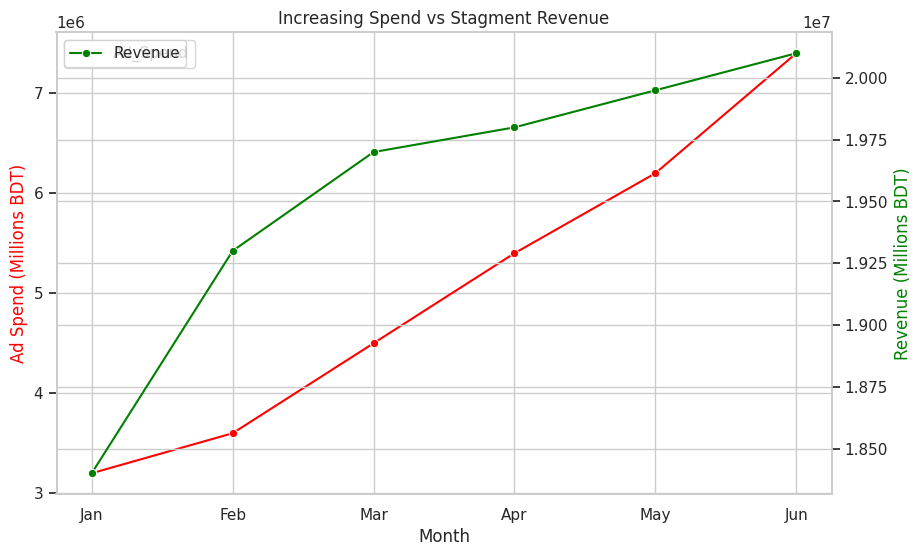

In [20]:
fig, ax1 = plt.subplots()
sns.lineplot(
    x = 'Month', y = 'Ad_Spend (BDT)', data = df_monthly, ax=ax1, color= 'red', marker= 'o', label = 'Ad_Spend'
)
ax1.set_ylabel('Ad Spend (Millions BDT)', color = 'red')

ax2 = ax1.twinx()
sns.lineplot(
  x = 'Month', y = 'Revenue (BDT)', data = df_monthly, ax= ax2, color= 'green', marker= 'o', label = 'Revenue'
)
ax2.set_ylabel('Revenue (Millions BDT)', color = 'green')

plt.title('Increasing Spend vs Stagment Revenue')
plt.show()

**Conversion Rate Decay**

Comparison of Coversion Rate from January to June

/tmp/ipykernel_4064/1340984065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


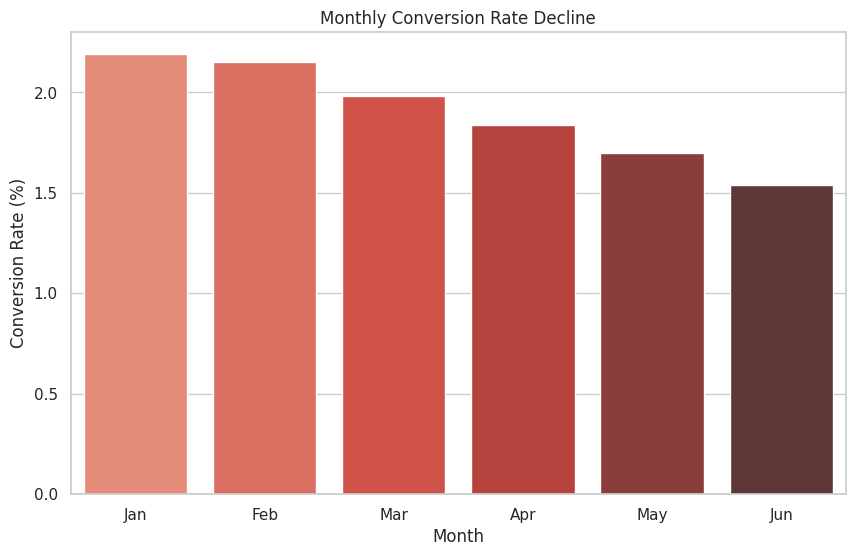

In [22]:
df_monthly['Conversion_Rate'] = ((df_monthly['Orders'] / df_monthly['Sessions']) * 100).round(2)
sns.barplot(
    x = 'Month', y = 'Conversion_Rate', data = df_monthly, palette= 'Reds_d'
)
plt.ylabel('Conversion Rate (%)')
plt.title('Monthly Conversion Rate Decline')
plt.show()

**Findings:**

Despite the increase in traffic and spend, revenue is stalling because:


*   **Decreasing Conversion Rate**

*   **Diminishing Returns on Ad Spend**

*   **Declining Average Order Value**





# **CAC, ROAS, and Conversion Rate by channel for June**

Applying the formulas for CAC, ROAS and Conversion Rate to the June dataset

In [24]:
df_channel['CAC'] = (df_channel['Spend'] / df_channel['Orders']).round(2)
df_channel['ROAS'] = (df_channel['Revenue'] / df_channel['Spend']).round(2)
df_channel['Conversion_Rate'] = ((df_channel['Orders'] / df_channel['Sessions']) * 100).round(2)

df_channel.loc[df_channel['Channel'] == 'Organic Search', 'ROAS'] = 0
print(df_channel[['Channel', 'CAC', 'ROAS', 'Conversion_Rate']])

          Channel      CAC  ROAS  Conversion_Rate
0    Facebook Ads   941.18  1.94             1.31
1      Google Ads   641.03  3.16             2.05
2  Organic Search     0.00  0.00             1.75
3           Email   214.29  9.33             1.35
4       Affiliate  2250.00  0.33             0.69


**Channel ROI (ROAS) Breakdown**

ROAS by Channel for June

/tmp/ipykernel_4064/2122371798.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


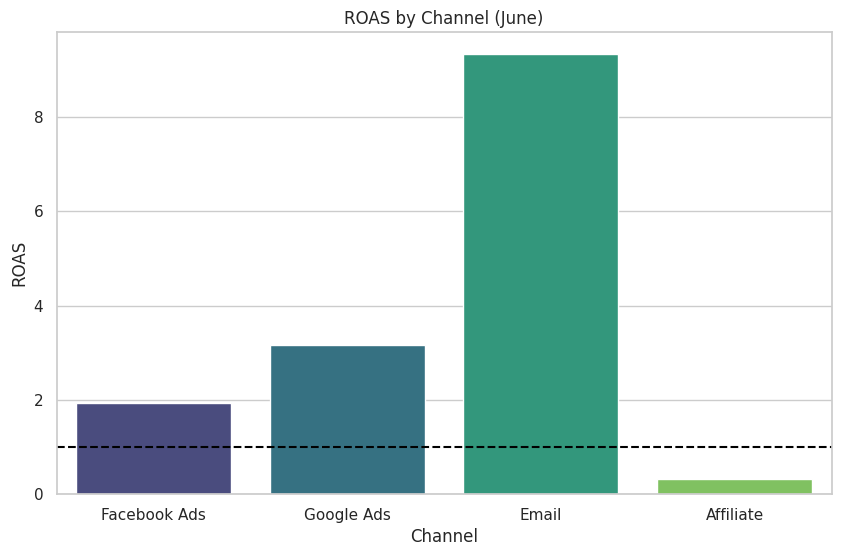

In [27]:
sns.barplot(
    x = 'Channel', y = 'ROAS', data = df_channel[df_channel['Spend'] > 0], palette= 'viridis'
)
plt.axhline(1, color='black', ls='--')
plt.title('ROAS by Channel (June)')
plt.show()

**Findings:**

*   Google Ads is your most efficient paid channel with a conversion rate of 2.05


*   Emails also hold a good position with a ROAS score of 9.33


*   Affiliate is the worst performer, costing 2,250 BDT per order while only generating 300,000 BDT in total revenue.



# **Retention Analysis**

Comparing the acquisition of new users against their likelihood to return.

In [29]:
#Dataset 4: Customer Cohort Snapshot
cohort_data = {
    'Month': ['Jan', 'Feb', 'Mar', 'Apr', 'May'],
    'Users_Acquired': [182000, 201000, 238000, 274000, 308000],
    'Re_Purchased': [29000, 30500, 31800, 32600, 33400]
}

df_retention = pd.DataFrame(cohort_data)
df_retention['Retention_Rate'] = (df_retention['Re_Purchased'] / df_retention['Users_Acquired'] * 100).round(2)
print(df_retention[['Month', 'Retention_Rate']])
df_retention.to_csv('cohort_data.csv', index = False)

  Month  Retention_Rate
0   Jan           15.93
1   Feb           15.17
2   Mar           13.36
3   Apr           11.90
4   May           10.84


**Retention Leaky Bucket**

Retention Rate over the acquisition months

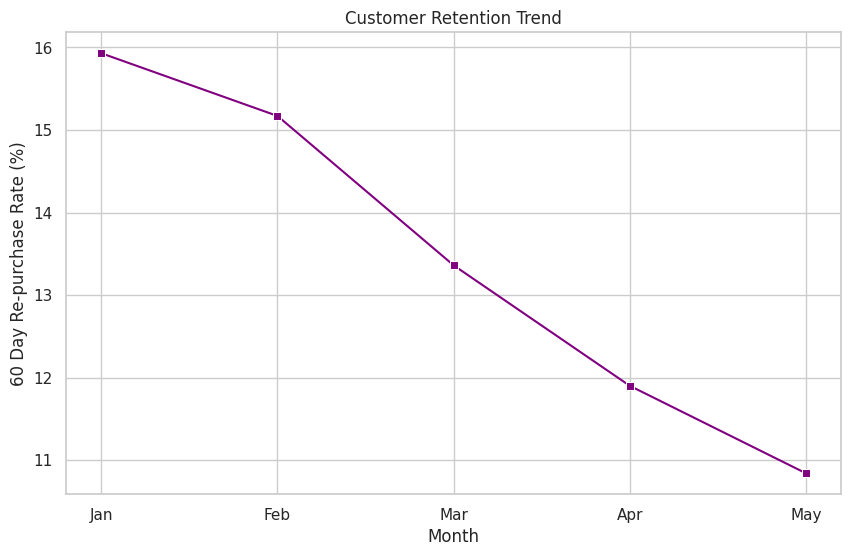

In [30]:
sns.lineplot(
    x = 'Month', y = 'Retention_Rate', data = df_retention, marker = 's', color= 'purple'
)
plt.ylabel('60 Day Re-purchase Rate (%)')
plt.title('Customer Retention Trend')
plt.show()

**Data Evidence:**

Retention dropped from 15.9% in January to 10.8% in May.  
​This proves that while we are acquiring more users, the quality/loyalty of these users is lower.

# **Category Performance Analysis**



In [31]:
# Dataset 3: Category Performance
category_data = {
    'Category': ['Electronics', 'Fashion', 'Home & Living', 'Beauty'],
    'Orders': [3100, 4200, 2200, 1000],
    'Revenue': [9800000, 5400000, 3300000, 1600000],
    'AOV': [3161, 1286, 1500, 1600]
}

df_category = pd.DataFrame(category_data)
df_category.to_csv('category_data.csv', index = False)

#Identifying the strongest product categories
strongest_volume = df_category.loc[df_category['Orders'].idxmax()]
strongest_revenue = df_category.loc[df_category['Revenue'].idxmax()]
strongest_aov = df_category.loc[df_category['AOV'].idxmax()]

print(f"Strongest Volume Category: {strongest_volume['Category']} ({strongest_volume['Orders']} orders)")
print(f"Strongest by Revenue: {strongest_revenue['Category']} ({strongest_revenue['Revenue']} BDT)" )
print(f"Strongest by AOV: {strongest_aov['Category']} ({strongest_aov['AOV']} BDT)")


Strongest Volume Category: Fashion (4200 orders)
Strongest by Revenue: Electronics (9800000 BDT)
Strongest by AOV: Electronics (3161 BDT)


**Category Portfolio Map**

A bubble Chart shows us Orders and Revenue compared to different Category

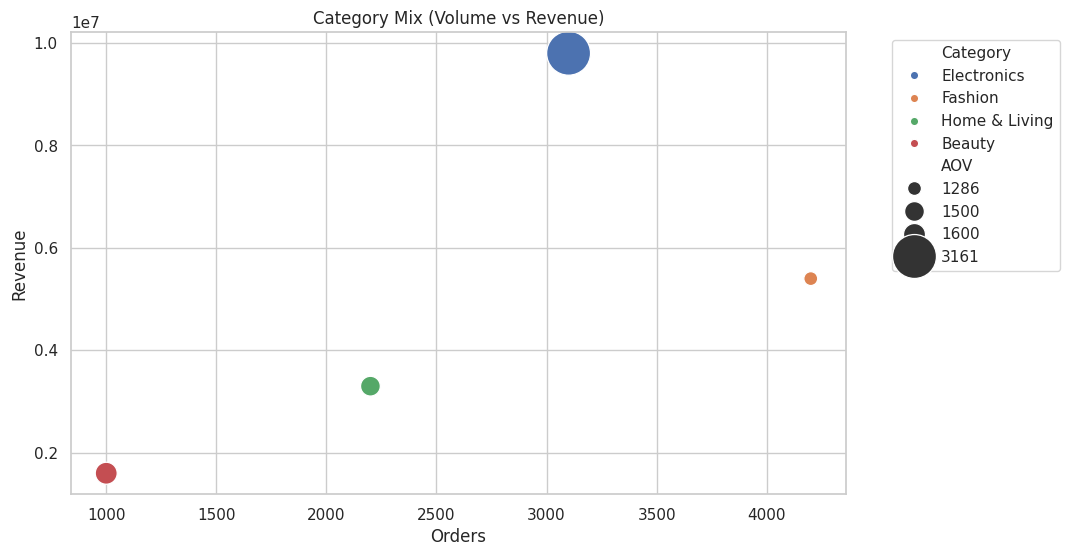

In [33]:
sns.scatterplot(
    x = 'Orders', y = 'Revenue', data = df_category, size= 'AOV', hue=  'Category', sizes=(100, 1000)
)
plt.title('Category Mix (Volume vs Revenue)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

**Findings**


*   **Strongest by Volume (Orders):** Fashion (4,200 orders)
*   **Strongest by Revenue:** Electronics generating 9,800,000 BDT, nearly 49% of the total monthly revenue.


*   **Strongest by Average Order Value (AOV):** Electronics at 3,161 BDT per order.



